# Protagonist Extraction under Occlusion — IoU vs. IoU + Face-ID Clustering

| Stage | Model / Method | Output |
|---|---|---|
| Face detection | `YoloFace11Detector` | per-frame boxes + 5-pt keypoints |
| Baseline tracking | `IouTracker` | IoU-linked tracks (fragment on occlusion) |
| Face-ID embeddings | `AdaFaceWrapper` (IResNet-50) | 512-d L2-normalised per tracklet |
| Protagonist tracker | `FaceClusterTracker` — IoU tracklets + **global face-ID clustering** | single merged protagonist track |

This notebook contrasts two ways of turning per-frame face detections into a
single **protagonist** track, and shows why identity clustering is needed.

## The video and the problem

`fi_protagonist.mp4` is a ~15 s talking-head clip with one protagonist. Two
things break naive tracking:

1. **Occlusion from a transition effect** around the middle of the clip: a
   dissolve briefly blends frames, so the protagonist's face jumps position.
   `IouTracker` — which links boxes by spatial overlap — cannot bridge the gap
   and **starts a new track id for the second half of the same person**.
2. **Background mispredictions**: the detector occasionally fires on a
   background face-like region, producing short spurious tracks.

Goal: recover **one** clean protagonist track spanning the whole clip, despite
the occlusion split, while leaving the mispredictions out.

**Colour key used throughout:**

- 🟩 **green** — the selected protagonist track
- 🟨 **yellow** — a *different* track id that is actually the **same person**
  (the fragment IoU failed to merge)
- 🟦 **blue** — a background misprediction

In [1]:
from exordium import FIXTURE_DIR
from exordium.video.core.io import get_video_metadata

video_path = FIXTURE_DIR / "video" / "fi_protagonist.mp4"
print(f"Video: {video_path.name}  exists={video_path.exists()}")

meta = get_video_metadata(video_path)
print(
    f"  {meta['num_frames']} frames @ {meta['fps']:.1f} fps  "
    f"({meta['width']}×{meta['height']})  {meta['duration']:.2f}s"
)

/Volumes/UGREEN/Dev/exordium/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Video: fi_protagonist.mp4  exists=True
  383 frames @ 25.0 fps  (1280×720)  15.32s


objc[7117]: Class AVFFrameReceiver is implemented in both /Volumes/UGREEN/Dev/exordium/.venv/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1093003a8) and /opt/homebrew/Cellar/ffmpeg/8.1.2/lib/libavdevice.62.3.102.dylib (0x129ec4328). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7117]: Class AVFAudioReceiver is implemented in both /Volumes/UGREEN/Dev/exordium/.venv/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1093003f8) and /opt/homebrew/Cellar/ffmpeg/8.1.2/lib/libavdevice.62.3.102.dylib (0x129ec4378). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


## Detect faces

We run the detector at `conf=0.5` so the faint background mispredictions are
included — they are exactly what the protagonist tracker must reject.

In [2]:
from exordium.video.deep.adaface import AdaFaceWrapper
from exordium.video.face.detector.yolo11 import YoloFace11Detector

detector = YoloFace11Detector(device_id=None, conf=0.5)
encoder = AdaFaceWrapper(backbone="ir_50", device_id=None)

video_dets = detector.detect_video(video_path)
total_dets = sum(len(fd) for fd in video_dets)
multi = sum(1 for fd in video_dets if len(fd) > 1)
print(f"Frames: {len(video_dets)}  detections: {total_dets}  frames with >1 face: {multi}")

2026-07-07 20:49:10 INFO YoloFace11Detector loaded 'yolo11n-pose_widerface' on cpu (conf=0.5).
2026-07-07 20:49:11 INFO AdaFace (ir_50) loaded to cpu.


Frames: 383  detections: 404  frames with >1 face: 20


## Visualisation helpers

`draw_frames` loads a few key frames and paints each detection with the colour
assigned to its track. We inspect four moments: before the occlusion, a frame
with a background misprediction, the transition itself, and after the occlusion.

In [3]:
import cv2
import matplotlib.pyplot as plt

from exordium.video.core.io import load_frames

GREEN, YELLOW, BLUE = (0, 200, 0), (245, 205, 0), (0, 130, 255)  # RGB
ROLE_COLOR = {"protagonist": GREEN, "same-person fragment": YELLOW, "misprediction": BLUE}
KEY_FRAMES = [60, 91, 175, 300]


def draw_frames(frame_ids, tracks, role_of):
    """Return RGB frames with each detection boxed in its track's colour."""
    frames = load_frames(video_path, frame_ids)  # (T, 3, H, W) RGB uint8
    imgs = []
    for k, fid in enumerate(frame_ids):
        img = frames[k].permute(1, 2, 0).numpy().copy()
        for tid, track in tracks.items():
            det = next((d for d in track if d.frame_id == fid), None)
            if det is None:
                continue
            x1, y1, x2, y2 = (int(v) for v in det.bb_xyxy.tolist())
            color = ROLE_COLOR[role_of[tid]]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(
                img, f"id{tid}", (x1, max(y1 - 8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
            )
        imgs.append(img)
    return imgs


def show(imgs, frame_ids, suptitle):
    fig, axes = plt.subplots(1, len(imgs), figsize=(4.2 * len(imgs), 3.2))
    for ax, img, fid in zip(axes, imgs, frame_ids):
        ax.imshow(img)
        ax.set_title(f"frame {fid}")
        ax.axis("off")
    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    plt.show()

## Baseline — `IouTracker`

IoU tracking links each detection to the open track with the highest overlap.
It produces clean tracklets, but at the occlusion the face jumps, overlap drops
to zero, and a **new track id** is opened for the second half — so the single
protagonist ends up as **two different ids**. We colour each track by identity:
the selected protagonist is green, and any *other* track whose AdaFace embedding
matches it (cosine ≥ 0.6) is the **same person** in yellow; the rest are
mispredictions in blue.

In [4]:
import torch

from exordium.video.core import FaceClusterTracker, IouTracker

iou = IouTracker(verbose=False, max_lost=10, iou_threshold=0.3)
iou.label(video_dets, min_score=0.5, max_lost=10, iou_threshold=0.3)

# Embed each IoU track (reuse the clustering tracker's tracklet embedding).
embed = FaceClusterTracker(encoder=encoder, min_det_score=0.5)
track_emb = {tid: embed._tracklet_embedding(t) for tid, t in iou.tracks.items()}

# Protagonist = track maximising on-screen time * face size.
prot_id = max(iou.tracks, key=lambda t: len(iou.tracks[t]) * iou.tracks[t].bb_size(0.0))


def cos(a, b):
    return float(torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)))


iou_role = {}
for tid in iou.tracks:
    if tid == prot_id:
        iou_role[tid] = "protagonist"
    elif cos(track_emb[tid], track_emb[prot_id]) >= 0.6:
        iou_role[tid] = "same-person fragment"
    else:
        iou_role[tid] = "misprediction"

print(f"IoU tracks: {len(iou.tracks)}")
print(f"{'id':>3} {'len':>4} {'span':>11} {'role':>22}")
for tid, t in sorted(iou.tracks.items(), key=lambda kv: -len(kv[1])):
    span = f"{t.first_detection().frame_id}-{t.last_detection().frame_id}"
    print(f"{tid:>3} {len(t):>4} {span:>11} {iou_role[tid]:>22}")

same = [tid for tid, r in iou_role.items() if r in ("protagonist", "same-person fragment")]
print(f"\nThe protagonist identity is split across {len(same)} IoU ids: {sorted(same)}")

IoU tracks: 6
 id  len        span                   role
  2  215     168-382            protagonist
  0  182       0-181   same-person fragment
  4    3     266-276          misprediction
  3    2     182-183          misprediction
  1    1       91-91          misprediction
  5    1     276-276          misprediction

The protagonist identity is split across 2 IoU ids: [0, 2]


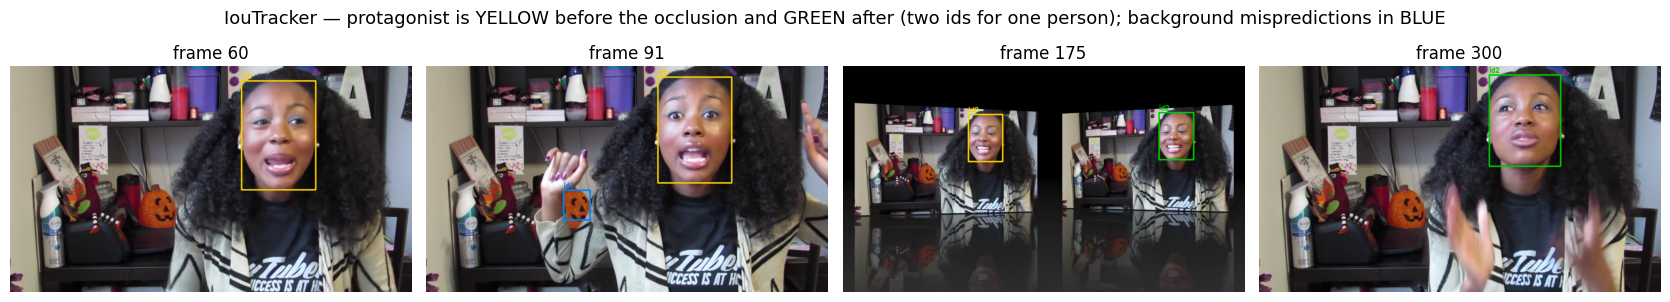

In [5]:
show(
    draw_frames(KEY_FRAMES, iou.tracks, iou_role),
    KEY_FRAMES,
    "IouTracker — protagonist is YELLOW before the occlusion and GREEN after "
    "(two ids for one person); background mispredictions in BLUE",
)

Notice frame 175 (the transition): the **same person is boxed twice** — one id
in yellow and one in green — because the dissolve briefly yields two detections
and IoU has already switched identity. This is the failure the next step fixes.

## Protagonist tracker — `FaceClusterTracker` (IoU tracklets + face-ID clustering)

The clustering tracker keeps the same IoU tracklets, embeds each one with
AdaFace, and clusters all tracklets **jointly** by identity. The two protagonist
fragments — despite the occlusion gap — land in the same cluster and merge into
**one** track spanning the whole clip, while the mispredictions stay separate.
`run()` chains label → cluster → select_protagonist.

In [6]:
tracker = FaceClusterTracker(
    encoder=encoder,
    iou_threshold=0.3,
    max_lost=10,
    distance_threshold=0.4,
    samples_per_track=5,
    min_det_score=0.5,
)
# run() chains label -> cluster -> select_protagonist and returns the Track.
protagonist = tracker.run(video_dets, min_score=0.5)

print(
    f"IoU tracklets: {tracker.n_tracklets}  ->  identities after clustering: {tracker.n_identities}"
)
print(
    f"Protagonist id{protagonist.track_id}: {len(protagonist)} detections, span {protagonist.first_detection().frame_id}-{protagonist.last_detection().frame_id} (video has {meta['num_frames']} frames)"
)

# Protagonist green, everything else (mispredictions) blue.
cluster_role = {
    tid: ("protagonist" if tid == protagonist.track_id else "misprediction")
    for tid in tracker.tracks
}

IoU tracklets: 6  ->  identities after clustering: 4
Protagonist id0: 397 detections, span 0-382 (video has 383 frames)


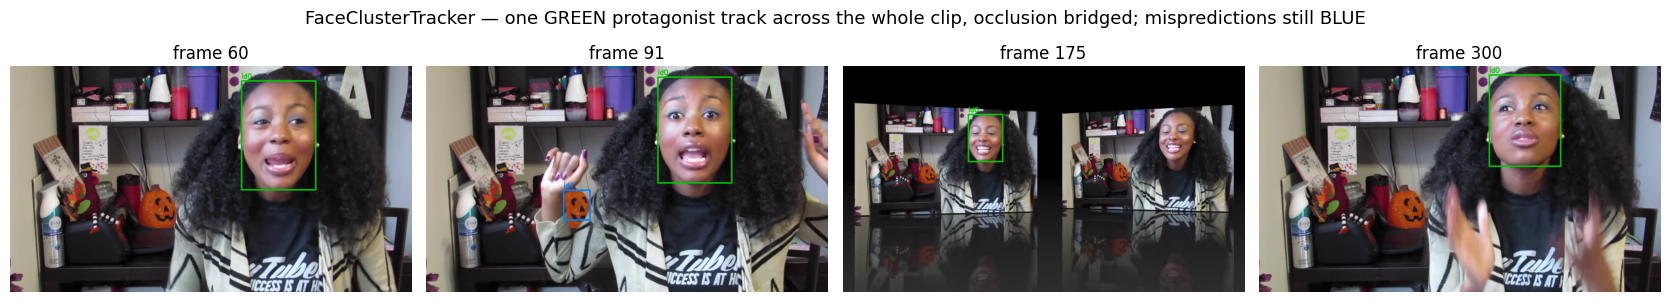

In [7]:
show(
    draw_frames(KEY_FRAMES, tracker.tracks, cluster_role),
    KEY_FRAMES,
    "FaceClusterTracker — one GREEN protagonist track across the whole clip, "
    "occlusion bridged; mispredictions still BLUE",
)

## Summary — the two methods side by side

In [8]:
import tempfile
from pathlib import Path

from exordium.video.core import Track

n_mispred_iou = sum(1 for r in iou_role.values() if r == "misprediction")
n_mispred_cluster = tracker.n_identities - 1

print("IouTracker (baseline)")
print(f"  protagonist split into {len(same)} track ids (occlusion breaks the track)")
print(f"  background mispredictions: {n_mispred_iou} separate tracks")
print()
print("FaceClusterTracker (IoU tracklets + face-ID clustering)")
print(
    f"  protagonist: 1 merged track, {len(protagonist)} detections, full span "
    f"{protagonist.first_detection().frame_id}-{protagonist.last_detection().frame_id}"
)
print(f"  background mispredictions: {n_mispred_cluster} separate identities (not merged in)")

with tempfile.TemporaryDirectory() as tmp:
    out = Path(tmp) / "protagonist.track"
    protagonist.save(out)
    reloaded = Track().load(out)
    print(
        f"\nSaved protagonist track ({out.name}); round-trip OK: "
        f"{reloaded.frame_ids() == protagonist.frame_ids()}"
    )

IouTracker (baseline)
  protagonist split into 2 track ids (occlusion breaks the track)
  background mispredictions: 4 separate tracks

FaceClusterTracker (IoU tracklets + face-ID clustering)
  protagonist: 1 merged track, 397 detections, full span 0-382
  background mispredictions: 3 separate identities (not merged in)

Saved protagonist track (protagonist.track); round-trip OK: True
